In [99]:
import gymnasium as gym
import numpy as np
import torch
from torch import nn
from torch import optim
from collections import deque
import random
import matplotlib.pyplot as plt

In [100]:
class NeuralNetwork1(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(21, 2048),
            nn.ReLU(),
            nn.Linear(2048, 2048),
            nn.ReLU(),
            nn.Linear(2048, 4),
        )

    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits

In [101]:
class NeuralNetwork2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(21, 2048),
            nn.ReLU(),
            nn.Linear(2048, 2048),
            nn.ReLU(),
            nn.Linear(2048, 4),
        )

    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits

In [102]:
model = NeuralNetwork1()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
model = model.to(device)
model2 = NeuralNetwork2()
model2 = model2.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

cuda


In [103]:
def build_env():
    env = gym.make("gymnasium_2048:gymnasium_2048/TwentyFortyEight-v0", size=4, max_pow=16)
    env.reset()
    return env

In [104]:
def process(tile):
    for i in range(len(tile)):
        if tile[i]!=0:
            return i
    return 0

In [105]:
def features(state):
    states = state.flatten()
    tile = []
    tiles = []
    for i in range(len(states)):
        tile.append(states[i])
        if i%16 == 15:
            tiles.append(tile)
            tile = []
    for i,tile in enumerate(tiles):
        tiles[i] = process(tile)
    max_corner_tile = max(tiles[0],tiles[3],tiles[12],tiles[15])/16
    max_tile = max(tiles)/16
    n = np.argmax(tiles)
    neibours = []
    left = [0,4,8,12]
    up = [0,1,2,3]
    right = [3,7,11,15]
    down = [12,13,14,15]
    if n not in left : neibours.append(2**tiles[n-1])
    if n not in right : neibours.append(2**tiles[n+1])
    if n not in up : neibours.append(2**tiles[n-4])
    if n not in down : neibours.append(2**tiles[n+4])
    neigbours = np.array(neibours)
    max_tile_neigbours = np.log2(neigbours.mean())/16
    sum=0
    for tile in tiles:
        sum+=2**tile
    sum = np.log2(sum/len(tiles))/16
    n_empty = 0
    for tile in tiles:
        if tile == 0:
            n_empty+=1
    n_empty = n_empty/16
    for tile in tiles:
        tile = tile/7
    feature = np.array([max_corner_tile,max_tile,max_tile_neigbours,sum,n_empty] + tiles)
    return feature

In [106]:
def q_hat_action(feature):
    feature = torch.tensor(feature, dtype=torch.float32)
    feature = feature.to(device)
    return torch.argmax(model(feature))

In [107]:
def q_hat_prime_action(feature):
    feature = torch.tensor(feature, dtype=torch.float32)
    feature = feature.to(device)
    return (torch.argmax(model2(feature))).detach()

In [108]:
def q_hat(feature,action):
    feature = torch.tensor(feature, dtype=torch.float32)
    feature = feature.to(device)
    return model(feature)[action] 

In [109]:
def q_hat_prime(feature):
    feature = torch.tensor(feature,dtype=torch.float32)
    feature = feature.to(device)
    return max(model(feature))

In [110]:
def DQN(env,episodes,N,gamma,epsilon,c,batch_size=64):
    D = deque(maxlen=N)
    episode_rewards = []
    episode_steps = []
    total_steps = 0
    for episode in range(episodes):
        epsilon = max(0.05, epsilon * 0.99925)
        state,_ = (env.reset())
        state = features(state)
        possibleactions = [0,1,2,3]
        if np.random.rand() < epsilon:
            action = np.random.choice(possibleactions).item()
        else :
            action = q_hat_action(state).cpu().numpy().item()           
        done = False
        steps = 0
        total_reward = 0
        while(True):
            next_state, reward, done, _, _ = env.step(action)
            if np.array_equal(next_state, state):
                reward = -1
            total_reward += reward
            if np.random.rand()<epsilon:
                next_action = (np.random.choice(possibleactions)).item()
            else:   
                next_action = q_hat_action(state).cpu().numpy().item()
            D.append((state,action,reward,features(next_state),done))
            steps += 1
            total_steps += 1
            if done == True:
                break
            state = features(next_state)
            action = next_action
            if steps % 4 != 3:
                continue   
            batch = random.sample(D, min(len(D), batch_size))
            states,actions,rewards,next_states,dones = zip(*batch)
            states = torch.tensor(np.array(states), dtype=torch.float32).to(device)
            actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1).to(device)
            rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
            next_states = torch.tensor(np.array(next_states), dtype=torch.float32).to(device)
            dones = torch.tensor(dones, dtype=torch.float32).to(device)
            current_q = model(states).gather(1,actions).squeeze(1)
            with torch.no_grad():
                next_actions = model(next_states).argmax(1).unsqueeze(1)
                next_q = model2(next_states).gather(1, next_actions).squeeze(1)
                target_q = rewards + (gamma * next_q * (1 - dones))
            loss = nn.MSELoss()(current_q,target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if total_steps%c==0:
                model2.load_state_dict(model.state_dict())
        episode_rewards.append(total_reward)
        episode_steps.append(steps)
        print(f"Episode: {episode}, Reward: {total_reward}, Steps: {steps}")
    return episode_rewards, episode_steps


In [111]:
def main():
    gamma = 0.99
    capacity = 2000000
    epsilon_start = 1
    episodes = 5000
    c = 1000
    window = 20
    env = build_env()
    episode_rewards, episode_steps = DQN(env, episodes, capacity, gamma, epsilon_start, c)
    def moving_average(values, window_size):
        if len(values) < window_size:
            return np.array(values)
        return np.convolve(values, np.ones(window_size) / window_size, mode='valid')

    reward_ma = moving_average(episode_rewards, window)
    steps_ma = moving_average(episode_steps, window)
    episodes_ma = np.arange(len(reward_ma)) + window - 1

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(episodes_ma, reward_ma, marker='o', markersize=2)
    plt.title(f'Training Reward per Episode (MA {window})')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(episodes_ma, steps_ma, marker='o', markersize=2, color='orange')
    plt.title(f'Training Steps per Episode (MA {window})')
    plt.xlabel('Episode')
    plt.ylabel('Steps')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    total_reward = 0  
    for i in range(100):
        state, _ = env.reset()
        state = features(state)
        while(True):
            if np.random.rand() < 0.05:
                action = np.random.randint(0,4)
            else :
                action = q_hat_action(state).cpu().numpy().item()
            state, reward, terminated, truncated, _ = env.step(action)
            state = features(state)
            total_reward += reward
            if terminated or truncated:
                print(f"Episode ended.{total_reward} , {i}")
                break
    print(f"Test episode total reward: {total_reward/100}")


Episode: 0, Reward: 1352, Steps: 178
Episode: 1, Reward: 1192, Steps: 143
Episode: 2, Reward: 644, Steps: 103
Episode: 3, Reward: 1320, Steps: 164
Episode: 4, Reward: 1312, Steps: 142
Episode: 5, Reward: 672, Steps: 96
Episode: 6, Reward: 1228, Steps: 165
Episode: 7, Reward: 640, Steps: 102
Episode: 8, Reward: 260, Steps: 57
Episode: 9, Reward: 3168, Steps: 309
Episode: 10, Reward: 2096, Steps: 247
Episode: 11, Reward: 2448, Steps: 259
Episode: 12, Reward: 1340, Steps: 159
Episode: 13, Reward: 672, Steps: 104
Episode: 14, Reward: 1304, Steps: 150
Episode: 15, Reward: 2372, Steps: 238
Episode: 16, Reward: 2532, Steps: 272
Episode: 17, Reward: 1016, Steps: 120
Episode: 18, Reward: 596, Steps: 93
Episode: 19, Reward: 1348, Steps: 144
Episode: 20, Reward: 1304, Steps: 160
Episode: 21, Reward: 1060, Steps: 143
Episode: 22, Reward: 1136, Steps: 134
Episode: 23, Reward: 616, Steps: 99
Episode: 24, Reward: 736, Steps: 114
Episode: 25, Reward: 520, Steps: 91
Episode: 26, Reward: 620, Steps: 92


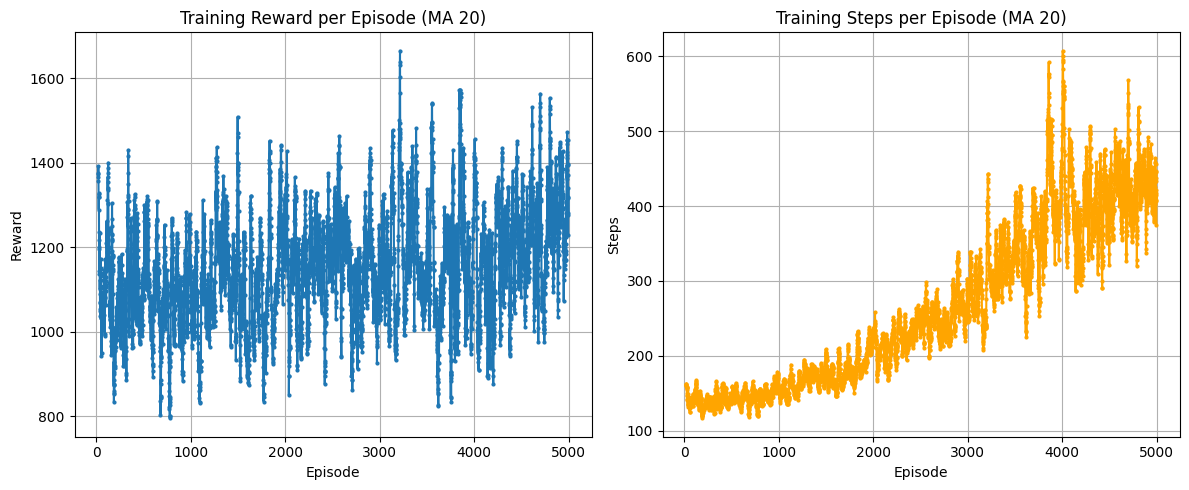

Episode ended.1336 , 0
Episode ended.3144 , 1
Episode ended.3924 , 2
Episode ended.4580 , 3
Episode ended.6764 , 4
Episode ended.8216 , 5
Episode ended.10660 , 6
Episode ended.13780 , 7
Episode ended.15232 , 8
Episode ended.17092 , 9
Episode ended.18704 , 10
Episode ended.20748 , 11
Episode ended.21968 , 12
Episode ended.23720 , 13
Episode ended.25336 , 14
Episode ended.27068 , 15
Episode ended.28984 , 16
Episode ended.30288 , 17
Episode ended.30956 , 18
Episode ended.31696 , 19
Episode ended.32784 , 20
Episode ended.34080 , 21
Episode ended.36504 , 22
Episode ended.38788 , 23
Episode ended.41188 , 24
Episode ended.42548 , 25
Episode ended.43192 , 26
Episode ended.44504 , 27
Episode ended.45940 , 28
Episode ended.47492 , 29
Episode ended.50220 , 30
Episode ended.53364 , 31
Episode ended.56120 , 32
Episode ended.57000 , 33
Episode ended.59340 , 34
Episode ended.60776 , 35
Episode ended.61452 , 36
Episode ended.64464 , 37
Episode ended.65764 , 38
Episode ended.68260 , 39
Episode ended.71

In [112]:
if __name__ == "__main__":
    main()